### Import Libraries

In [111]:
import matplotlib.pyplot as plt  # a useful graphing tool for plotting a line plot
import numpy as np  # library for handling numeric data in Python
from sklearn import datasets, linear_model, model_selection

### The Diabetes Dataset

Ten baseline variables, age, sex, body mass index, average blood pressure, and six blood serum measurements were obtained for each of n = 442 diabetes patients, as well as the response of interest, a quantitative measure of disease progression one year after baseline.

First 10 columns are numeric predictive values.<br/>
Column 11 is a quantitative measure of disease progression one year after baseline

For more information [click here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html#sklearn.datasets.load_diabetes).<br/>
For an explanation of the feature variables used, [see here](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

In [112]:
# Load the diabetes dataset
# Attribute return_X_y=True, forces the method to return a tuple of the form (data, target).
# data   : an ndarray of shape (442, 10) - the data matrix
# target : an ndarray of shape (442,) - the regression target
X, y = datasets.load_diabetes(return_X_y=True)
print(X.shape)  # print the shape of the data
print(X[0])  # print the first observation

(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [113]:
# Select all rows but only the 3rd column : bmi (body mass index)
X = X[:, 2]
# X is now a 1D array of target values
# Print the first 15 values from this 1D array:
print(X[0:15])

[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469 -0.04069594
 -0.04716281 -0.00189471  0.06169621  0.03906215 -0.08380842  0.01750591
 -0.02884001 -0.00189471 -0.02560657]


In [114]:
# Reshape this 1D array to be a 2D array (as required for plotting).
# reshape(n_rows, n_columns): a parameter equal to -1 means that the
# corresponding dimension is calculated automatically.
# Now the shape of X is (442, 1)
# Print the first 15 values from this 2D array:
X = X.reshape((-1, 1))
print(X[0:15])

[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]]


Split the feature data (X) and the target (y) into training and test data. 67% of the data will be used for training and 33% for evaluating the model.<br/>
Remember, 
> - X is a 2D array of shape (442, 10) and<br/>
> - y is a 2D array of shape (442, 1).

In [115]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33)

Now train the model with the X and y training sets:

In [116]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [117]:
def model_fit(col_num):
    X, y = datasets.load_diabetes(return_X_y=True)
    X = X[:, col_num]
    X = X.reshape((-1, 1))
    X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33)
    model = linear_model.LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return X_test, y_test, y_pred


def plot_predline_scatter(X_test, y_test, y_pred, feature):
    fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")
    ax.scatter(X_test, y_test, color="brown", edgecolors="black", alpha=0.7)
    ax.plot(X_test, y_pred, color="darkslateblue", linewidth=3)
    ax.set_xlabel("Scaled BMIs")
    ax.set_ylabel("Disease Progression")
    ax.set_title(f"A Graph Showing Diabetes Progresison Against {feature}")

    plt.show()

To evaluate the model:
1. Using the testing data, create predictions; these will lie in a straight line of course.
2. Visualise both the prediction line and the actual testing data (with a scatter plot).

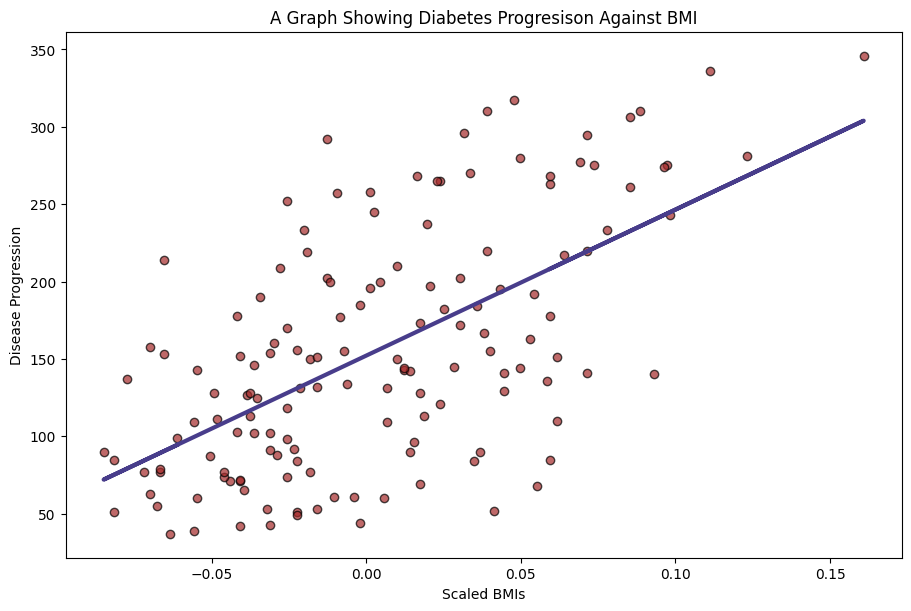

In [118]:
y_pred = model.predict(X_test)
plot_predline_scatter(X_test, y_test, y_pred, "BMI")

### Challenge: Plot a different variable from the dataset

Let's use the feature called **s1 tc, total serum cholesterol**. This is the 5th column and can be accessed with index=4.

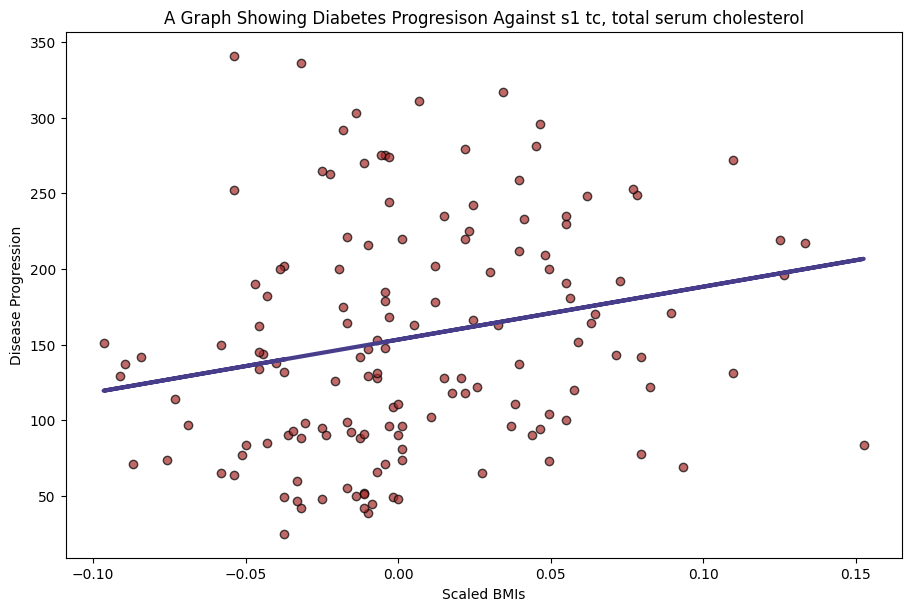

In [119]:
X_test, y_test, y_pred = model_fit(4)
plot_predline_scatter(X_test, y_test, y_pred, "s1 tc, total serum cholesterol")

This feature doesn't seem to be related to disease progression.<br/>
What about **bp average blood pressure**?

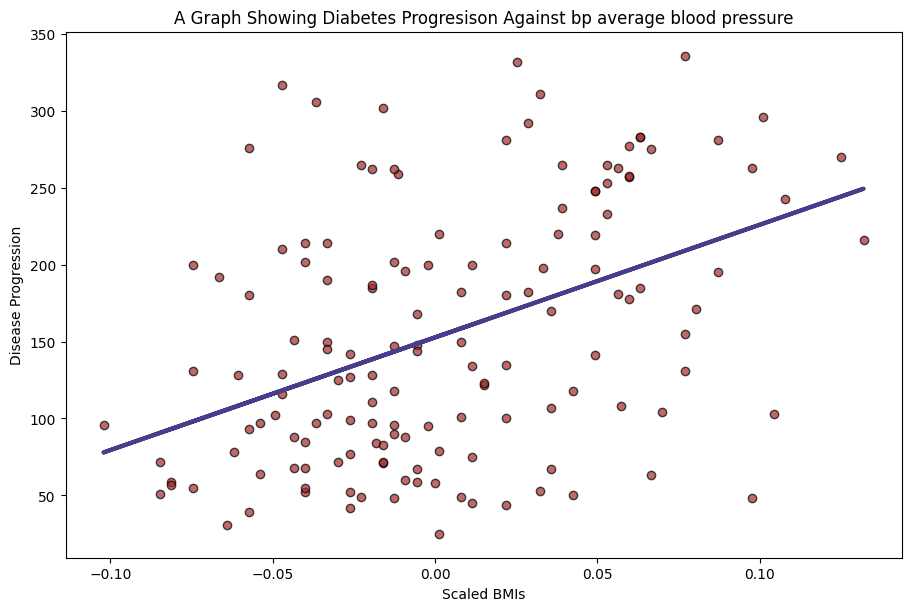

In [120]:
X_test, y_test, y_pred = model_fit(3)
plot_predline_scatter(X_test, y_test, y_pred, "bp average blood pressure")